<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW3_Classification_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание 3. Линейная классификация (base)**

### **Оценивание и штрафы**

С наступающим новым годом, друзья! Магистратура бежит быстро и мы бежим очень быстро, а зима — то время, когда хотелось бы бежать чуть медленнее. Поэтому это домашнее задание мы сделали сильно короче от его начальной версии!

Как всегда, каждая из задач имеет «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

В задании две части:

- Часть 1: написание логистической регрессии своими руками — уверенны, логлосс вы уже знаете как свои пять пальцев.
- Часть 2: решение задачи классификации на текстах.

In [2]:
%pylab inline
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.svm import SVC


from sklearn.metrics import accuracy_score, roc_auc_score

Populating the interactive namespace from numpy and matplotlib


In [3]:
from google.colab import drive # Если вы работаете в коллабе
drive.mount('/content/drive')

Mounted at /content/drive


# **Часть 1. Логистическая регрессия своими руками (5 баллов)**

Логистическая регрессия — безумно важная и удобная модель для понимания начальных концепций. Вы много практиковались с выведением формулы градиента логлосса, шага спуска, а в прошлом дз сделали SGD. Давайте сделаем ещё шаг вперед — и реализуем логистическую регрессию своими руками.

На практике, часто хватает алгоритмов из коробки. Но иногда очень удобно сделать свой алгоритм.

## **Теоретическая сноска: почему LogLoss'а так много**

Почти наверное (в математике это значит, во всех случаях, кроме множества размером 0) логлосс набил оскомину за несколько заданий. Давайте посмотрим на него ещё раз:

В логистической регрессии функция потерь

$$\text{LogLoss}(y, \hat{p}) = -\left(y\log \hat{p} + (1-y)\log (1-\hat{p})\right)$$

Зачем мы так долго с ней возимся?

#### **Пункт 1.**
Во-первых, это **следствие максимизации правдоподобия** при биномиальной модели.

Если считать, что целевая переменная (Y\in{0,1}) распределена как

$$P(Y=1 \mid x) = \hat{p}(x), \qquad P(Y=0\mid x) = 1-\hat{p}(x),$$
то правдоподобие выборки ( (x_i, y_i) )\ равно
$$L = \prod_{i=1}^n \hat{p}_i^{y_i}(1-\hat{p}_i)^{1-y_i}.$$

Максимизация $\log L$ эквивалентна минимизации LogLoss.
Таким образом, LogLoss — **единственная функция потерь, полностью согласованная с вероятностной моделью логистической регрессии**.

#### **Пункт 2.**

Во-вторых, логлосс поможет нам в будущем понять другие функции потерь. Так, например LogLoss является частным случаем **кросс-энтропии между истинным распределением и предсказанным**.

Для двух распределений $p$ (истинного) и $q$ (предсказанного) кросс-энтропия определяется как

$$H(p,q) = -\sum_{k} p(k)\log q(k).$$

В бинарном случае истинное распределение дискретно:

$$p = (y, 1-y), \qquad q = (\hat{p}, 1-\hat{p}),$$
и подстановка даёт

$$H(p,q) = -\left[y\log \hat{p} + (1-y)\log (1-\hat{p})\right] = \text{LogLoss}.$$


В общем, любим, жалуем и реализуем.




### **Задание 1. Реализуйте класс логистической регрессии, обучаемой с помощью:**

**Задание 1.1 (1.5 балла). Градиентного спуска**

**Задание 1.2 (1.5 балла). Стохастического градиентного спуска**

До этого вы писали код без ограничений. Здесь же необходимо соблюдать следующие условия:

- Градиентный спуск необходимо записать в векторном виде;
- Циклы средствами python допускается использовать только для итераций градиентного спуска;

**Класс градиентного спуска должен:**
- В качестве критерия останова использовать (одновременно):
  - проверку на евклидову норму разности весов на двух соседних итерациях задаваемого параметром `tolerance`;
  - достижение максимального числа итераций, задаваемого параметром `max_iter`.
- Обладать атрибутом `loss_history`. В нём после вызова метода fit должны содержаться значения функции потерь для всех итераций, начиная с первой (до совершения первого шага по антиградиенту). Данный атрибут необходим, чтобы проследить, что оптимизационный процесс действительно сходится;
- Инициализировать веса случайным образом или нулевым вектором (на ваш выбор).

Полезно [почитать](https://scikit-learn.org/stable/developers/develop.html).

**Шаблон класса описан ниже, вам нужно реализовать каждую из заготовленных функций.**

**ВАЖНО!** Мы заполняем данный шаблон, даже если он нам не нравится. Менять структуру класса и писать по-своему запрещено - за это будут сняты баллы.

In [4]:
import numpy as np
from sklearn.base import BaseEstimator

class LogReg(BaseEstimator):
    def __init__(self, gd_type='stochastic',
                 tolerance=1e-4, max_iter=1000, w0=None, eta=1e-2):
        """
        gd_type: 'full' or 'stochastic'
        tolerance: for stopping gradient descent
        max_iter: maximum number of steps in gradient descent
        w0: np.array of shape (d) — init weights
        eta: learning rate
        """
        self.gd_type = gd_type
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.w0 = w0
        self.w = None
        self.eta = eta
        self.loss_history = []

    def fit(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: self
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        ell, d = X.shape

        # инициализация весов
        if self.w0 is None:
            self.w = np.zeros(d, dtype=float)
        else:
            self.w = np.asarray(self.w0, dtype=float).copy()

        self.loss_history = []

        for _ in range(self.max_iter):
            w_prev = self.w.copy()

            if self.gd_type == 'full':
                # полный градиент
                grad = self.calc_gradient(X, y)
                self.w = self.w - self.eta * grad

                # loss считаем на всей выборке
                loss = self.calc_loss(X, y)
                self.loss_history.append(loss)

            elif self.gd_type == 'stochastic':
                # стохастический шаг (1 объект)
                i = np.random.randint(ell)
                Xi = X[i:i+1]
                yi = y[i:i+1]

                grad = self.calc_gradient(Xi, yi)
                self.w = self.w - self.eta * grad

                # loss считаем на всей выборке (как обычно в заданиях, чтобы видеть сходимость)
                loss = self.calc_loss(X, y)
                self.loss_history.append(loss)
            else:
                raise ValueError("gd_type must be 'full' or 'stochastic'")

            # критерий остановки по норме разности весов
            if np.linalg.norm(self.w - w_prev) < self.tolerance:
                break

        return self

    def sigmoid(self, x):
        # численно стабильная сигмоида
        x = np.asarray(x, dtype=float)
        out = np.empty_like(x, dtype=float)
        pos = x >= 0
        neg = ~pos
        out[pos] = 1.0 / (1.0 + np.exp(-x[pos]))
        exp_x = np.exp(x[neg])
        out[neg] = exp_x / (1.0 + exp_x)
        return out

    def predict_proba(self, X):
        if self.w is None:
            raise Exception('Not trained yet')

        X = np.asarray(X, dtype=float)
        scores = X @ self.w
        p1 = self.sigmoid(scores)
        p0 = 1.0 - p1

        # sklearn-формат: (n, 2) -> [P(y=0), P(y=1)]
        return np.vstack([p0, p1]).T

    def predict(self, X):
        if self.w is None:
            raise Exception('Not trained yet')

        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)

    def calc_gradient(self, X, y):
        """
        X: np.array of shape (ell, d) (ell can be equal to 1 if stochastic)
        y: np.array of shape (ell)
        ---
        output: np.array of shape (d)
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        # p = sigmoid(Xw)
        p = self.sigmoid(X @ self.w)

        # grad = (1/ell) X^T (p - y)
        ell = X.shape[0]
        grad = (X.T @ (p - y)) / ell
        return grad

    def calc_loss(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: float
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        p = self.sigmoid(X @ self.w)

        # защита от log(0)
        eps = 1e-15
        p = np.clip(p, eps, 1.0 - eps)

        # LogLoss = - mean( y log p + (1-y) log(1-p) )
        loss = -np.mean(y * np.log(p) + (1.0 - y) * np.log(1.0 - p))
        return float(loss)

Теперь проверим работу вашего класса на синтетических данных.

In [5]:
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=100000, n_features=20, n_informative=2,
    random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### **Задание 2 (0.6 балла)**

Теперь давайте тестировать модель.
1. Обучите свою логистическую регрессию на синтетических данных (0.2 балла) — на полном GD и SGD;
2. Cравните результат с моделью из библиотеки. Посчитайте roc-auc, accuracy, постройте ROC и PR кривые. , оцените разницу в производительности моделей по метрикам качества. Ответьте на вопросы:
- Какая показывает лучший результат? Почему?
- Есть ли что-то в модели из коробки, что по умолчанию делает её не равной вашей модели? Для ответа на этот вопрос вам может пригодитться [документация](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Её мы изучаем всегда, чтобы понимать тонкости реализации какого-либо метода в библиотеке. (0.4 балла)

In [6]:
lr_sgd = LogReg(gd_type='stochastic')
lr_sgd.fit(X_train, y_train)

lr_full = LogReg(gd_type='full')
lr_full.fit(X_train, y_train)


LogReg(gd_type='full')

My LogReg (SGD): ROC-AUC=0.9369 | PR-AUC=0.9375 | Accuracy=0.8625
My LogReg (full GD): ROC-AUC=0.9396 | PR-AUC=0.9394 | Accuracy=0.8673
sklearn LogisticRegression: ROC-AUC=0.9399 | PR-AUC=0.9389 | Accuracy=0.8681


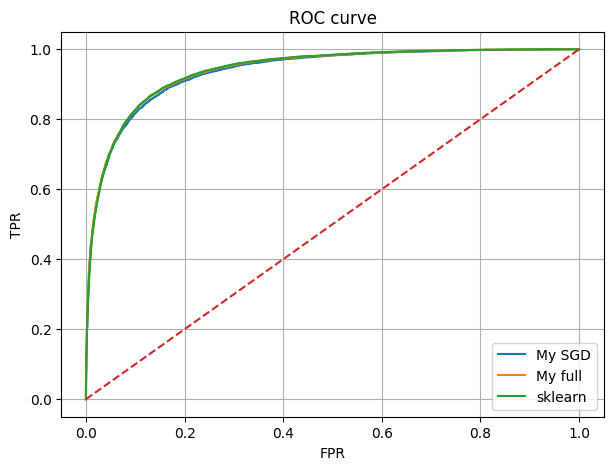

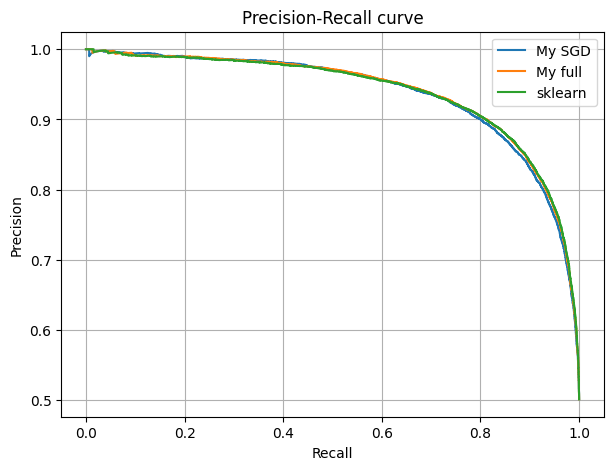

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, accuracy_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.linear_model import LogisticRegression


lr_sgd = LogReg(gd_type='stochastic', eta=1e-2, max_iter=2000, tolerance=1e-6)
lr_sgd.fit(X_train, y_train)

lr_full = LogReg(gd_type='full', eta=1e-2, max_iter=2000, tolerance=1e-6)
lr_full.fit(X_train, y_train)

sk_lr = LogisticRegression(
    penalty='l2',
    C=1e9,
    solver='lbfgs',
    max_iter=5000
)
sk_lr.fit(X_train, y_train)

proba_sgd = lr_sgd.predict_proba(X_test)[:, 1]
proba_full = lr_full.predict_proba(X_test)[:, 1]
proba_sk = sk_lr.predict_proba(X_test)[:, 1]

pred_sgd = (proba_sgd >= 0.5).astype(int)
pred_full = (proba_full >= 0.5).astype(int)
pred_sk = (proba_sk >= 0.5).astype(int)

def report(name, y_true, proba, pred):
    roc_auc = roc_auc_score(y_true, proba)
    acc = accuracy_score(y_true, pred)
    ap = average_precision_score(y_true, proba)
    print(f"{name}: ROC-AUC={roc_auc:.4f} | PR-AUC={ap:.4f} | Accuracy={acc:.4f}")

report("My LogReg (SGD)", y_test, proba_sgd, pred_sgd)
report("My LogReg (full GD)", y_test, proba_full, pred_full)
report("sklearn LogisticRegression", y_test, proba_sk, pred_sk)

plt.figure(figsize=(7, 5))
for name, proba in [
    ("My SGD", proba_sgd),
    ("My full", proba_full),
    ("sklearn", proba_sk),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC curve")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
for name, proba in [
    ("My SGD", proba_sgd),
    ("My full", proba_full),
    ("sklearn", proba_sk),
]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.grid(True)
plt.legend()
plt.show()

### **Задание 3 (0.4 балла)**

Для трех полученных моделей, визуализируйте прогнозы по данным на тестовой выборке. Для этого:
- получите прогнозы;
- сомжите данные, используя PCA. Не забудьте, что PCA полагает нулевое среднее и единичную дисперсию;
- покрасьте данные по прогнозам.

Как различаются графики для трёх моделей? И различаются ли?

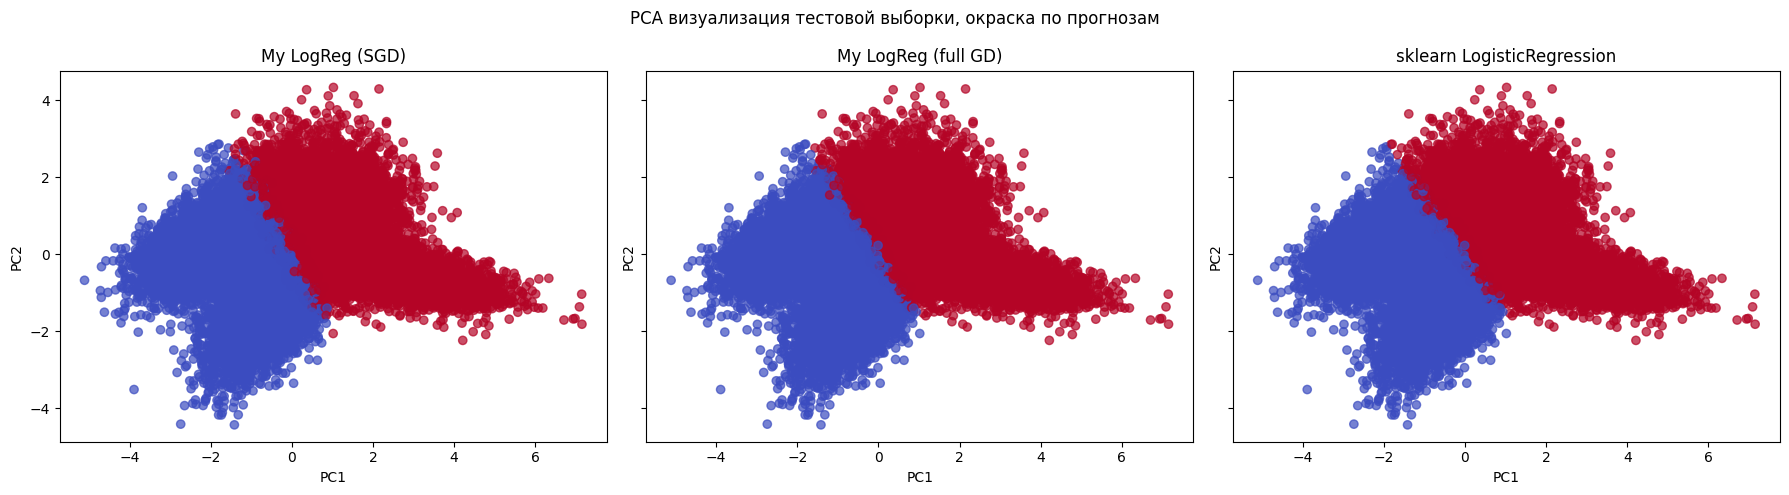

In [9]:

pred_sgd = lr_sgd.predict(X_test)
pred_full = lr_full.predict(X_test)
pred_sk = sk_lr.predict(X_test)

scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_scaled)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

models = [
    ("My LogReg (SGD)", pred_sgd),
    ("My LogReg (full GD)", pred_full),
    ("sklearn LogisticRegression", pred_sk),
]

for ax, (title, preds) in zip(axes, models):
    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=preds,
        cmap="coolwarm",
        alpha=0.7
    )
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle("PCA визуализация тестовой выборки, окраска по прогнозам")
plt.tight_layout()
plt.show()

# **Часть 2. Обучение моделей на текстовых данных. (5 баллов)**

 ### **Подготовка данных из реального мира.**

Ещё одна прелесть простых моделей — возможность решать с ними неструктурированные (изначально не табличные) задачи. Давайте посмотрим на это в действии на примере текстов.


Загрузите данные с конкурса  [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started/data?select=train.csv) (вам нужна только обучающая выборка, файл `train.csv`). Задача состоит в определении постов, сообщающих о чрезвычайной ситуации. В рамках домашнего задания, этот набор данных будет отличным полем для тренировки в обработке признаков.

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

PATH = "train.csv"   # файл в той же папке
data = pd.read_csv(PATH)

data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


### **Задание 10. Базовая предобработка (1.5 балла).**

- Выведите на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их пустой строкой (0.2 балла).

In [12]:

missing_info = data.isna().sum()
print("Пропуски по столбцам:")
print(missing_info)

data = data.fillna("")

Пропуски по столбцам:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


- Проанализируйте количество уникальных значений в столбцах, опустив `text`. Сделайте выводы. (0.5 балла)

In [13]:

for col in data.columns:
    if col != "text":
        print(f"{col}: {data[col].nunique()} уникальных значений")

id: 7613 уникальных значений
keyword: 222 уникальных значений
location: 3342 уникальных значений
target: 2 уникальных значений


- Проанализируйте соотношение классов в целевой переменной. Какое оно? Выберите метрику, с помощью которой будете оценивать модель.  (0.5 балла)

In [14]:

class_counts = data["target"].value_counts(normalize=True)
print("Доля классов:")
print(class_counts)

Доля классов:
target
0    0.57034
1    0.42966
Name: proportion, dtype: float64


- Объедините все три текстовых столбца в один для baseline (вам поможет конкатенация строк) (0.3 балла)

In [17]:
data["text_full"] = (
    data["keyword"].astype(str) + " " +
    data["location"].astype(str) + " " +
    data["text"].astype(str)
)

data[["text", "text_full"]].head()

,text,text_full
0,Our Deeds are the Reason of this #earthquake M...,Our Deeds are the Reason of this #earthquake...
1,Forest fire near La Ronge Sask. Canada,Forest fire near La Ronge Sask. Canada
2,All residents asked to 'shelter in place' are ...,All residents asked to 'shelter in place' ar...
3,"13,000 people receive #wildfires evacuation or...","13,000 people receive #wildfires evacuation ..."
4,Just got sent this photo from Ruby #Alaska as ...,Just got sent this photo from Ruby #Alaska a...


- Наконец, поделите данные на тренировочную и тестовую выборки. (0.2 балла)

In [19]:
from sklearn.model_selection import train_test_split

X = data["text_full"]   # объединённый текст
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y      # важно при дисбалансе классов
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 5329
Test size: 2284


### **Задание 11. Базовые модели. (1 балл).**

Данные, собираемые с сайтов, часто содержат мусор не информативный для моделей. Посмотрите, какого качества и насколько разнообразны данные здесь. Для этого:
- Примените CountVectorizer из sklearn к сырым даным. Какого размера получилась матрица? (0.3 балла)

In [22]:
import time
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

cv = CountVectorizer()  # сырой baseline
X_train_bow = cv.fit_transform(X_train)
X_test_bow = cv.transform(X_test)

print("CountVectorizer matrix shape (train):", X_train_bow.shape)
print("CountVectorizer matrix shape (test): ", X_test_bow.shape)
print("Vocab size:", len(cv.vocabulary_))


CountVectorizer matrix shape (train): (5329, 18506)
CountVectorizer matrix shape (test):  (2284, 18506)
Vocab size: 18506


- Обучите логистическую регрессию на полученном наборе. Модель возьмите из библиотеки. Какое качество по выбранной вами метрике у модели получилось на тестовых данных? (0.3 балла)

In [23]:
lr = LogisticRegression(max_iter=2000)  # baseline
t0 = time.time()
lr.fit(X_train_bow, y_train)
lr_time = time.time() - t0

lr_proba = lr.predict_proba(X_test_bow)[:, 1]
lr_pred = (lr_proba >= 0.5).astype(int)

In [24]:


print("\nLogReg results:")
print("  ROC-AUC:", roc_auc_score(y_test, lr_proba))
print("  PR-AUC: ", average_precision_score(y_test, lr_proba))
print("  Acc:   ", accuracy_score(y_test, lr_pred))
print("  Train time (s):", lr_time)


LogReg results:
  ROC-AUC: 0.8549641969484676
  PR-AUC:  0.8535294963229686
  Acc:    0.7981611208406305
  Train time (s): 2.7091803550720215


- Обучите SVC на тех же данных с гиперпараметрами по умолчанию. Измерьте качество на тестовых данных и опишите результат. Проанализируйте качество и скорость обучения.(0.4 балла)

In [25]:
svc = LinearSVC()
t0 = time.time()
svc.fit(X_train_bow, y_train)
svc_time = time.time() - t0

svc_scores = svc.decision_function(X_test_bow)
svc_pred = svc.predict(X_test_bow)

print("\nLinearSVC results:")
print("  ROC-AUC:", roc_auc_score(y_test, svc_scores))
print("  PR-AUC: ", average_precision_score(y_test, svc_scores))
print("  Acc:   ", accuracy_score(y_test, svc_pred))
print("  Train time (s):", svc_time)

print("\nSpeed comparison (train):")
print("  LogReg:", lr_time, "sec")
print("  LinearSVC:", svc_time, "sec")


LinearSVC results:
  ROC-AUC: 0.8355981609130658
  PR-AUC:  0.8221234802131157
  Acc:    0.7697022767075307
  Train time (s): 0.5120115280151367

Speed comparison (train):
  LogReg: 2.7091803550720215 sec
  LinearSVC: 0.5120115280151367 sec


### **Задание 12. Улучшение базовых моделей за счет данных. (0.3 балла).**

- Подберите гиперпараметры CountVectorizer так, чтобы признаков было минимум в 4 раза меньше, чем объектов, а качество модели при этом изменилось не более чем на $\pm 0.07$. Опишите подобранные гиперпараметры и на что они влияют.

Обучайте и логистическую регрессию, и SVC.

In [32]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score

# baseline
cv_base = CountVectorizer()
Xtr_base = cv_base.fit_transform(X_train)
Xte_base = cv_base.transform(X_test)

lr_base = LogisticRegression(max_iter=2000)
lr_base.fit(Xtr_base, y_train)
lr_base_roc = roc_auc_score(y_test, lr_base.predict_proba(Xte_base)[:, 1])

svc_base = LinearSVC()
svc_base.fit(Xtr_base, y_train)
svc_base_roc = roc_auc_score(y_test, svc_base.decision_function(Xte_base))

# улучшенный CountVectorizer
cv = CountVectorizer(
    lowercase=True,
    stop_words='english',
    min_df=3,
    max_df=0.9,
    token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
    max_features=1332
)

Xtr = cv.fit_transform(X_train)
Xte = cv.transform(X_test)

lr = LogisticRegression(max_iter=2000)
lr.fit(Xtr, y_train)
lr_roc = roc_auc_score(y_test, lr.predict_proba(Xte)[:, 1])

svc = LinearSVC()
svc.fit(Xtr, y_train)
svc_roc = roc_auc_score(y_test, svc.decision_function(Xte))

print("bf:", Xtr_base.shape[1])
print("rf:", Xtr.shape[1])

print("lrROC-AUC:", lr_roc, "Δ =", lr_roc - lr_base_roc)
print("lSVC ROC-AUC:", svc_roc, "Δ =", svc_roc - svc_base_roc)

bf: 18506
rf: 1332
lrROC-AUC: 0.8471088830527529 Δ = -0.0078553138957147
lSVC ROC-AUC: 0.8226268401235133 Δ = -0.012971320789552543


### **Задание 13. Улучшение базовых моделей за счет данных 2. (0.7 балла).**

В первом пункте мы склеили все строки в одну. Но можно было бы поступить иначе — и получить категории из `'keyword', 'location'`. Протестируйте такой подход на обеих моделях и замерьте качество. Улучшает ли это результат?

In [30]:
import numpy as np
from scipy.sparse import hstack

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score

# ===== векторизация текста =====
cv_text = CountVectorizer(
    lowercase=True,
    stop_words='english',
    min_df=3,
    max_df=0.9,
    max_features=1332
)

Xtr_text = cv_text.fit_transform(data.loc[X_train.index, "text"])
Xte_text = cv_text.transform(data.loc[X_test.index, "text"])

cv_kw = CountVectorizer()
Xtr_kw = cv_kw.fit_transform(data.loc[X_train.index, "keyword"])
Xte_kw = cv_kw.transform(data.loc[X_test.index, "keyword"])

cv_loc = CountVectorizer()
Xtr_loc = cv_loc.fit_transform(data.loc[X_train.index, "location"])
Xte_loc = cv_loc.transform(data.loc[X_test.index, "location"])

Xtr_all = hstack([Xtr_text, Xtr_kw, Xtr_loc])
Xte_all = hstack([Xte_text, Xte_kw, Xte_loc])

lr = LogisticRegression(max_iter=2000)
lr.fit(Xtr_all, y_train)
lr_roc = roc_auc_score(y_test, lr.predict_proba(Xte_all)[:, 1])

svc = LinearSVC()
svc.fit(Xtr_all, y_train)
svc_roc = roc_auc_score(y_test, svc.decision_function(Xte_all))

print("lr ROC-AUC:", lr_roc)
print("lsvc ROC-AUC:", svc_roc)
print("tf:", Xtr_all.shape[1])

lr ROC-AUC: 0.8476522069747301
lsvc ROC-AUC: 0.8146084117026262
tf: 4132


### **Задание 14. Улучшение базовых моделей путем подбора гиперпараметров. (1 балл).**
- Попробуйте подбирать разные гиперпараметры для логистической регрессии. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [34]:


Xtr_use = Xtr_all
Xte_use = Xte_all

best_lr = None

C_grid = [0.01, 0.1, 1, 10, 100]
class_weight_grid = [None, "balanced"]

for C in C_grid:
    for cw in class_weight_grid:
        model = LogisticRegression(max_iter=3000, C=C, class_weight=cw)
        model.fit(Xtr_use, y_train)

        proba = model.predict_proba(Xte_use)[:, 1]
        roc = roc_auc_score(y_test, proba)

        if (best_lr is None) or (roc > best_lr["roc"]):
            best_lr = {"C": C, "class_weight": cw, "roc": roc}

print("Best lr:", best_lr)

Best lr: {'C': 0.1, 'class_weight': None, 'roc': np.float64(0.8579655824440268)}


- Попробуйте подбирать разные гиперпараметры для модели SVC. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [38]:

best_svc = None

C_grid = [0.01, 0.1, 1, 10]
class_weight_grid = [None, "balanced"]

for C in C_grid:
    for cw in class_weight_grid:
        model = LinearSVC(C=C, class_weight=cw, max_iter=5000)
        model.fit(Xtr_use, y_train)

        scores = model.decision_function(Xte_use)
        roc = roc_auc_score(y_test, scores)

        if (best_svc is None) or (roc > best_svc["roc"]):
            best_svc = {"C": C, "class_weight": cw, "roc": roc}

print("Best lSVC:", best_svc)

Best lSVC: {'C': 0.01, 'class_weight': None, 'roc': np.float64(0.8583387509260758)}


Ваши выводы здесь.

### **Задание 14. (0.5 балла)**

Оформите два [пайплайна](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html):
- для модели регрессии
- для SVC модели

в пайплайн должны входить предобработка сырого датасета и обучение модели.

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

pipe_logreg = Pipeline([
    ("vectorizer", CountVectorizer(
        lowercase=True,
        stop_words="english",
        min_df=3,
        max_df=0.9,
        token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
        max_features=1332
    )),
    ("model", LogisticRegression(
        max_iter=3000,
        C=1,
        class_weight=None
    ))
])

pipe_logreg.fit(X_train, y_train)

logreg_roc = roc_auc_score(
    y_test,
    pipe_logreg.predict_proba(X_test)[:, 1]
)

print("lr pipeline ROC-AUC:", logreg_roc)

LogReg pipeline ROC-AUC: 0.8471088830527529


In [40]:
from sklearn.svm import LinearSVC

pipe_svc = Pipeline([
    ("vectorizer", CountVectorizer(
        lowercase=True,
        stop_words="english",
        min_df=3,
        max_df=0.9,
        token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
        max_features=1332
    )),
    ("model", LinearSVC(
        C=0.01,
        class_weight=None,
        max_iter=5000
    ))
])

pipe_svc.fit(X_train, y_train)

svc_scores = pipe_svc.decision_function(X_test)
svc_roc = roc_auc_score(y_test, svc_scores)

print("lSVC pipeline ROC-AUC:", svc_roc)

lSVC pipeline ROC-AUC: 0.856718167046485


**Опишите общие мысли о работе. Это место для вашей рефлексии, не обязательное, но полезное.**  🐤